# Variational Autoencoder

First generative network that we are going to see.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/DeepLearningAndGenerativeModelsCourse/res')
import plot_lib

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from plot_lib import plot_data, plot_data_np, plot_model, set_default
set_default()

In [ ]:
# Load MNIST dataset
# TRAIN dataset
# Pytorch already has some datasets available for downlaod
train_dataset = datasets.MNIST('../data', train=True, download=True,
                # transforms that we want to apply when iterating the dataset
                   transform=transforms.ToTensor())

# The datasoar will iterate through the dataset and load the data in memory
train_loader = torch.utils.data.DataLoader(
                        train_dataset,
                        batch_size=64, shuffle=True)

# TEST dataset
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False,
                   transform=transforms.ToTensor()),
                    batch_size=1000, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.39MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.71MB/s]


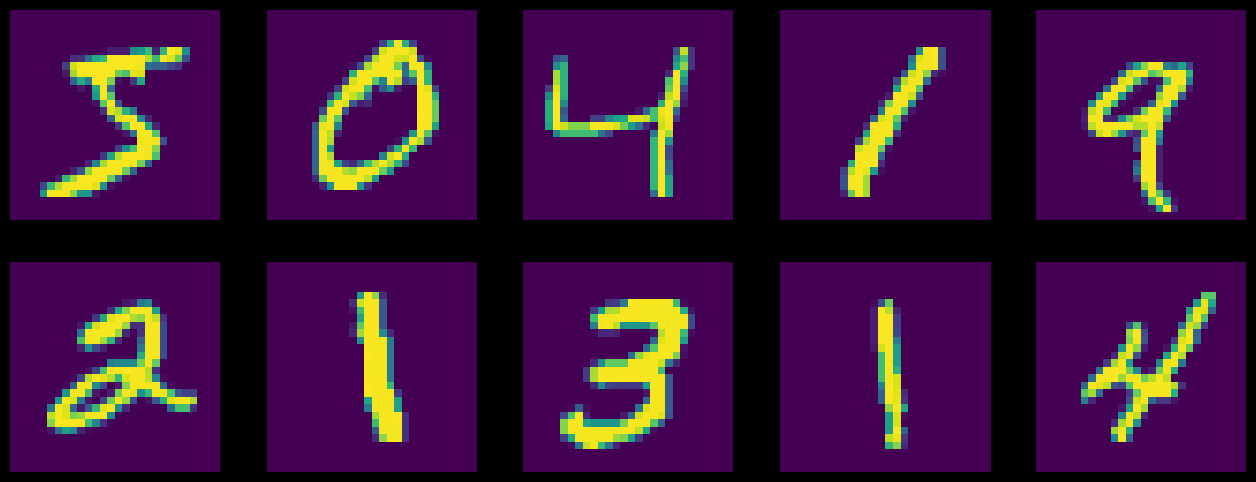

In [ ]:
# show some images
to_pil = transforms.ToPILImage()
plt.figure(figsize=(16, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    image, _ = train_loader.dataset.__getitem__(i) # load one image
    plt.imshow(to_pil(image))
    plt.axis('off')

In [ ]:
# set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# Let's define our VAE

class VAE(nn.Module):
    def __init__(
        self,
        image_channels=1,
        hidden_size=64,
        latent_size=2
    ):
        super(VAE, self).__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size

        ## encoder ##
        self.Encoder = nn.Sequential(nn.Conv2d(image_channels, 16, 4, stride = 2, padding=1), #16x14x14   [(W−K+2P)/S]+1
                                        nn.ReLU(),
                                        nn.Conv2d(16, 32, 4, stride = 2, padding=1), #32x7x7
                                        nn.ReLU(),
                                        nn.Conv2d(32, 64, 3, stride = 2, padding=1), #64x4x4
                                        nn.ReLU(),
                                        nn.Conv2d(64, self.hidden_size, 4, stride = 1, padding=0), #64x1x1
                                        nn.ReLU(),
                                        nn.Flatten())  #hidden_size


        # define mean
        self.encoder_mean = nn.Linear(self.hidden_size, self.latent_size)
        #define logvar
        self.encoder_logvar = nn.Linear(self.hidden_size, self.latent_size)

        self.resize_fc = nn.Linear(self.latent_size, self.hidden_size)

        ## decoder ##
        self.Decoder = nn.Sequential(nn.ConvTranspose2d( self.hidden_size, 64, 4, 1, 0), #4x4  (W - 1)S -2P + (K - 1) + 1
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 64, 32, 3, 2, 1), #7x7
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 32, 16, 4, 2, 1), #14x14
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 16, 1, 4, 2, 1), #28x28
                                    nn.Sigmoid())

    def sample(self, log_var, mean):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean) # reparametrization trick

    def KL_loss(self, log_var, mean):
        return -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    def forward(self, x):
        x = self.Encoder(x)
        log_var = self.encoder_logvar(x)
        mean = self.encoder_mean(x)

        z = self.sample(log_var, mean)

        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)

        x = self.Decoder(x)

        return x, log_var, mean

    def generate_img(self, z):
        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)
        return self.Decoder(x)


vae = VAE().to(device)
print(vae)

VAE(
  (Encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=2, bias=True)
  (resize_fc): Linear(in_features=2, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2)

In [ ]:
# define Optimizer and Loss
optimizer = torch.optim.Adam(vae.parameters(), lr=0.001)

# as loss lets use BCE (Binary Cross Entropy)
bce_loss = nn.BCELoss(reduction="sum")

In [ ]:
# TRAIN!!!

PATH = "./res/vae.pth"

vae.train()

for epoch in range(10):
    for batch_idx, (data, target) in enumerate(train_loader):
        # send to device
        data = data.to(device)

        optimizer.zero_grad()
        output, log_var, mean = vae(data)

        bce = bce_loss(output, data)
        kl = vae.KL_loss(log_var, mean)
        loss = bce + kl
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tBCE: {:.2f} KL: {:.2f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), bce.item(), kl.item()))

    # save model every epoch
    #torch.save(vae.state_dict(), PATH)

Train Epoch: 0 [0/60000 (0%)]	BCE: 33392.05 KL: 0.43
Train Epoch: 0 [12800/60000 (21%)]	BCE: 11619.32 KL: 182.81
Train Epoch: 0 [25600/60000 (43%)]	BCE: 11867.87 KL: 241.29
Train Epoch: 0 [38400/60000 (64%)]	BCE: 10148.70 KL: 287.87
Train Epoch: 0 [51200/60000 (85%)]	BCE: 10379.17 KL: 277.87
Train Epoch: 1 [0/60000 (0%)]	BCE: 10531.87 KL: 281.77
Train Epoch: 1 [12800/60000 (21%)]	BCE: 10195.98 KL: 345.42
Train Epoch: 1 [25600/60000 (43%)]	BCE: 9961.50 KL: 339.08
Train Epoch: 1 [38400/60000 (64%)]	BCE: 9932.28 KL: 332.94
Train Epoch: 1 [51200/60000 (85%)]	BCE: 9950.39 KL: 333.33
Train Epoch: 2 [0/60000 (0%)]	BCE: 9701.56 KL: 331.38
Train Epoch: 2 [12800/60000 (21%)]	BCE: 9827.17 KL: 343.42
Train Epoch: 2 [25600/60000 (43%)]	BCE: 9530.28 KL: 356.34
Train Epoch: 2 [38400/60000 (64%)]	BCE: 9856.00 KL: 348.69
Train Epoch: 2 [51200/60000 (85%)]	BCE: 9226.63 KL: 360.83
Train Epoch: 3 [0/60000 (0%)]	BCE: 9322.79 KL: 359.49
Train Epoch: 3 [12800/60000 (21%)]	BCE: 9792.90 KL: 367.05
Train Epoch:

In [ ]:
#Load a set of weights
vae.load_state_dict(torch.load(PATH))

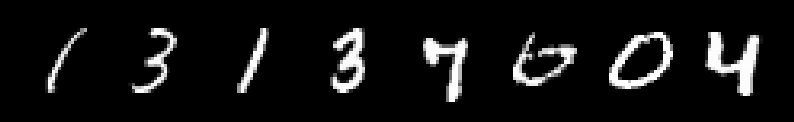

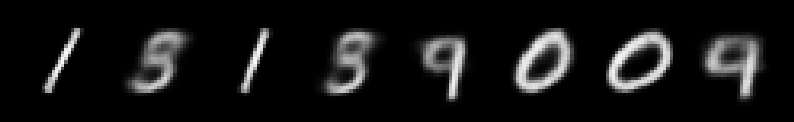

In [ ]:
# TEST
image, target = next(iter(test_loader)) # load one batch
image = image.to(device)

vae.eval()

out, _, _ = vae(image)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image[:8])
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out[:8])
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([8, 2])


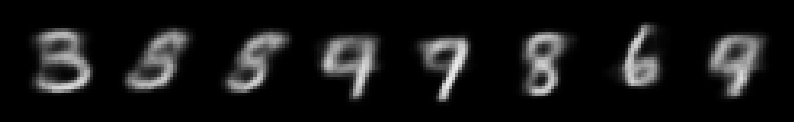

In [ ]:
# GENERATE!!!!
z = torch.randn(8,2).to(device)
print(z.size())
generated_samples = vae.generate_img(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()


In [ ]:
# Let's visualize latent space
image, target = next(iter(test_loader)) # load one batch
image = image.to(device)
_, log_var, mean = vae(image)

# sample noise in the latent space
z = vae.sample(log_var, mean)

z = z.cpu().detach().numpy()

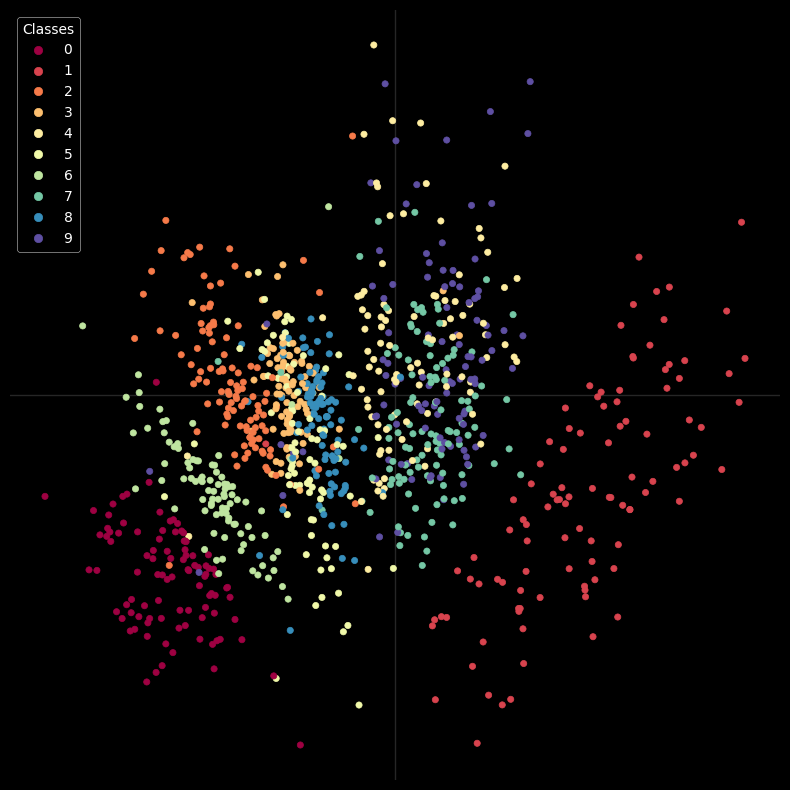

In [ ]:
# plot
# scale and move the coordinates so they fit [-1; 1] range
def scale_to_01_range(x):
    # compute the distribution range
    value_range = (np.max(x) - np.min(x))

    # move the distribution so that it starts from zero
    # by extracting the minimal value from all its values
    starts_from_zero = x - np.min(x)

    # make the distribution fit [-1; 1] by dividing by its range
    return 2*(starts_from_zero / value_range) - 1

# extract x and y coordinates representing the positions of the images on T-SNE plot
tx = z[:, 0]
ty = z[:, 1]

tx = scale_to_01_range(tx)
ty = scale_to_01_range(ty)

z[:, 0] = tx
z[:, 1] = ty

plot_data_np(z, target.numpy(), legend = True)

In [ ]:
# function to plot interpolation of generated sample
def plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3), n=12):
    w = 28
    img = np.zeros((n*w, n*w))
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y]]).to(device)
            x_hat = vae.generate_img(z)
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat.cpu().detach().numpy()
    plt.imshow(img, extent=[*r0, *r1])
    plt.axis('off')

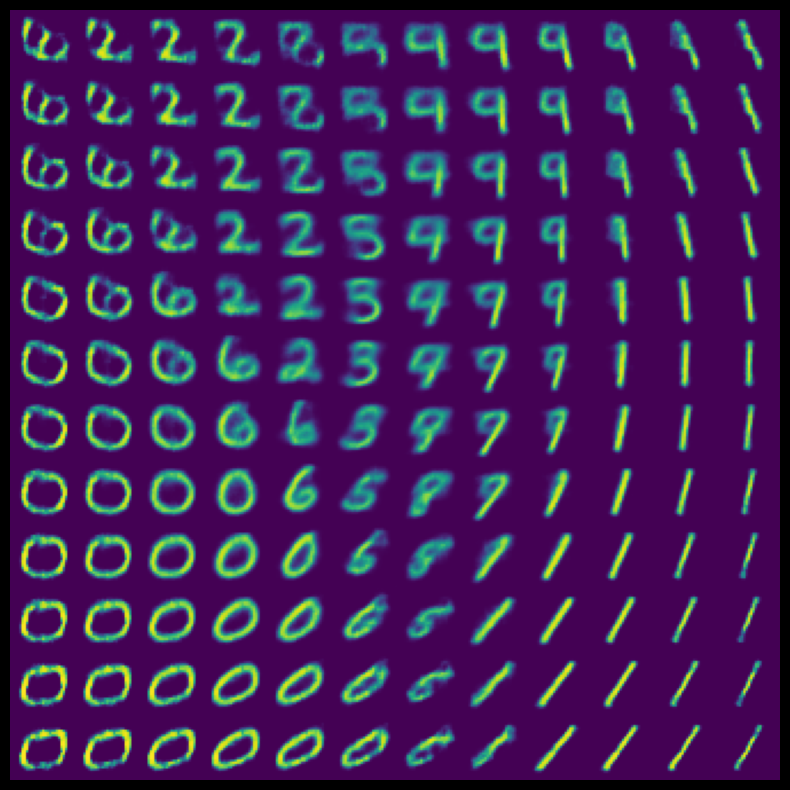

In [ ]:
plot_reconstructed(vae)

In [ ]:
# Ex1: train the VAE incrementing the latent space, removing the reparametrization trick, changing the weights of the KL loss (e.g. 10*kl)

In [ ]:
import torch.nn as nn
import torch.nn.init as init

def reset_weights(m):
    if isinstance(m, nn.Linear):
        init.kaiming_uniform_(m.weight)  # o init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

vae3.apply(reset_weights)

VAE3(
  (Encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=2, bias=True)
  (resize_fc): Linear(in_features=2, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2

In [ ]:
# Let's define our VAE

class VAE1(nn.Module):
    def __init__(
        self,
        image_channels=1,
        hidden_size=64,
        latent_size=8
    ):
        super(VAE1, self).__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size

        ## encoder ##
        self.Encoder = nn.Sequential(nn.Conv2d(image_channels, 16, 4, stride = 2, padding=1), #16x14x14   [(W−K+2P)/S]+1
                                        nn.ReLU(),
                                        nn.Conv2d(16, 32, 4, stride = 2, padding=1), #32x7x7
                                        nn.ReLU(),
                                        nn.Conv2d(32, 64, 3, stride = 2, padding=1), #64x4x4
                                        nn.ReLU(),
                                        nn.Conv2d(64, self.hidden_size, 4, stride = 1, padding=0), #64x1x1
                                        nn.ReLU(),
                                        nn.Flatten())  #hidden_size


        # define mean
        self.encoder_mean = nn.Linear(self.hidden_size, self.latent_size)
        #define logvar
        self.encoder_logvar = nn.Linear(self.hidden_size, self.latent_size)

        self.resize_fc = nn.Linear(self.latent_size, self.hidden_size)

        ## decoder ##
        self.Decoder = nn.Sequential(nn.ConvTranspose2d( self.hidden_size, 64, 4, 1, 0), #4x4  (W - 1)S -2P + (K - 1) + 1
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 64, 32, 3, 2, 1), #7x7
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 32, 16, 4, 2, 1), #14x14
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 16, 1, 4, 2, 1), #28x28
                                    nn.Sigmoid())

    def sample(self, log_var, mean):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean) # reparametrization trick

    def KL_loss(self, log_var, mean):
        return -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    def forward(self, x):
        x = self.Encoder(x)
        log_var = self.encoder_logvar(x)
        mean = self.encoder_mean(x)

        z = self.sample(log_var, mean)

        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)

        x = self.Decoder(x)

        return x, log_var, mean

    def generate_img(self, z):
        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)
        return self.Decoder(x)


vae1 = VAE1().to(device)
print(vae1)

VAE1(
  (Encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=8, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=8, bias=True)
  (resize_fc): Linear(in_features=8, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2

In [ ]:
# Let's define our VAE

class VAE2(nn.Module):
    def __init__(
        self,
        image_channels=1,
        hidden_size=64,
        latent_size=2
    ):
        super(VAE2, self).__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size

        ## encoder ##
        self.Encoder = nn.Sequential(nn.Conv2d(image_channels, 16, 4, stride = 2, padding=1), #16x14x14   [(W−K+2P)/S]+1
                                        nn.ReLU(),
                                        nn.Conv2d(16, 32, 4, stride = 2, padding=1), #32x7x7
                                        nn.ReLU(),
                                        nn.Conv2d(32, 64, 3, stride = 2, padding=1), #64x4x4
                                        nn.ReLU(),
                                        nn.Conv2d(64, self.hidden_size, 4, stride = 1, padding=0), #64x1x1
                                        nn.ReLU(),
                                        nn.Flatten())  #hidden_size


        # define mean
        self.encoder_mean = nn.Linear(self.hidden_size, self.latent_size)
        #define logvar
        self.encoder_logvar = nn.Linear(self.hidden_size, self.latent_size)

        self.resize_fc = nn.Linear(self.latent_size, self.hidden_size)

        ## decoder ##
        self.Decoder = nn.Sequential(nn.ConvTranspose2d( self.hidden_size, 64, 4, 1, 0), #4x4  (W - 1)S -2P + (K - 1) + 1
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 64, 32, 3, 2, 1), #7x7
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 32, 16, 4, 2, 1), #14x14
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 16, 1, 4, 2, 1), #28x28
                                    nn.Sigmoid())

    def sample(self, log_var, mean):
        std = torch.exp(0.5 * log_var)
        return torch.normal(mean, std) # no re-parametrization trick

    def KL_loss(self, log_var, mean):
        return -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    def forward(self, x):
        x = self.Encoder(x)
        log_var = self.encoder_logvar(x)
        mean = self.encoder_mean(x)

        z = self.sample(log_var, mean)

        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)

        x = self.Decoder(x)

        return x, log_var, mean

    def generate_img(self, z):
        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)
        return self.Decoder(x)


vae2 = VAE2().to(device)
print(vae2)

VAE2(
  (Encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=2, bias=True)
  (resize_fc): Linear(in_features=2, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2

In [ ]:
# Let's define our VAE

class VAE3(nn.Module):
    def __init__(
        self,
        image_channels=1,
        hidden_size=64,
        latent_size=2
    ):
        super(VAE3, self).__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size

        ## encoder ##
        self.Encoder = nn.Sequential(nn.Conv2d(image_channels, 16, 4, stride = 2, padding=1), #16x14x14   [(W−K+2P)/S]+1
                                        nn.ReLU(),
                                        nn.Conv2d(16, 32, 4, stride = 2, padding=1), #32x7x7
                                        nn.ReLU(),
                                        nn.Conv2d(32, 64, 3, stride = 2, padding=1), #64x4x4
                                        nn.ReLU(),
                                        nn.Conv2d(64, self.hidden_size, 4, stride = 1, padding=0), #64x1x1
                                        nn.ReLU(),
                                        nn.Flatten())  #hidden_size


        # define mean
        self.encoder_mean = nn.Linear(self.hidden_size, self.latent_size)
        #define logvar
        self.encoder_logvar = nn.Linear(self.hidden_size, self.latent_size)

        self.resize_fc = nn.Linear(self.latent_size, self.hidden_size)

        ## decoder ##
        self.Decoder = nn.Sequential(nn.ConvTranspose2d( self.hidden_size, 64, 4, 1, 0), #4x4  (W - 1)S -2P + (K - 1) + 1
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 64, 32, 3, 2, 1), #7x7
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 32, 16, 4, 2, 1), #14x14
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 16, 1, 4, 2, 1), #28x28
                                    nn.Sigmoid())

    def sample(self, log_var, mean):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean) # reparametrization trick

    def KL_loss(self, log_var, mean):
        return -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    def forward(self, x):
        x = self.Encoder(x)
        log_var = self.encoder_logvar(x)
        mean = self.encoder_mean(x)

        z = self.sample(log_var, mean)

        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)

        x = self.Decoder(x)

        return x, log_var, mean

    def generate_img(self, z):
        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)
        return self.Decoder(x)


vae3 = VAE3().to(device)
print(vae3)

VAE3(
  (Encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=2, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=2, bias=True)
  (resize_fc): Linear(in_features=2, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(16, 1, kernel_size=(4, 4), stride=(2, 2

In [ ]:
# define Optimizer and Loss
optimizer = torch.optim.Adam(vae1.parameters(), lr=0.001)

# as loss lets use BCE (Binary Cross Entropy)
bce_loss = nn.BCELoss(reduction="sum")

In [ ]:
# TRAIN!!!

PATH = "./res/vae.pth"

vae1.train()

for epoch in range(10):
    for batch_idx, (data, target) in enumerate(train_loader):
        # send to device
        data = data.to(device)

        optimizer.zero_grad()
        output, log_var, mean = vae1(data)

        bce = bce_loss(output, data)
        kl = vae.KL_loss(log_var, mean)
        loss = bce + kl
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tBCE: {:.2f} KL: {:.2f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), bce.item(), kl.item()))

    # save model every epoch
    #torch.save(vae.state_dict(), PATH)

Train Epoch: 0 [0/60000 (0%)]	BCE: 35727.00 KL: 1.75
Train Epoch: 0 [12800/60000 (21%)]	BCE: 13040.35 KL: 251.18
Train Epoch: 0 [25600/60000 (43%)]	BCE: 10137.27 KL: 578.72
Train Epoch: 0 [38400/60000 (64%)]	BCE: 8979.23 KL: 601.94
Train Epoch: 0 [51200/60000 (85%)]	BCE: 7810.03 KL: 751.42
Train Epoch: 1 [0/60000 (0%)]	BCE: 8331.43 KL: 752.36
Train Epoch: 1 [12800/60000 (21%)]	BCE: 7529.53 KL: 811.53
Train Epoch: 1 [25600/60000 (43%)]	BCE: 7426.78 KL: 742.23
Train Epoch: 1 [38400/60000 (64%)]	BCE: 7117.96 KL: 826.22
Train Epoch: 1 [51200/60000 (85%)]	BCE: 7206.42 KL: 829.09
Train Epoch: 2 [0/60000 (0%)]	BCE: 7684.38 KL: 824.40
Train Epoch: 2 [12800/60000 (21%)]	BCE: 7451.63 KL: 797.20
Train Epoch: 2 [25600/60000 (43%)]	BCE: 6968.15 KL: 803.30
Train Epoch: 2 [38400/60000 (64%)]	BCE: 6983.05 KL: 828.66
Train Epoch: 2 [51200/60000 (85%)]	BCE: 7285.16 KL: 817.10
Train Epoch: 3 [0/60000 (0%)]	BCE: 7002.92 KL: 864.21
Train Epoch: 3 [12800/60000 (21%)]	BCE: 7017.87 KL: 815.01
Train Epoch: 3 [

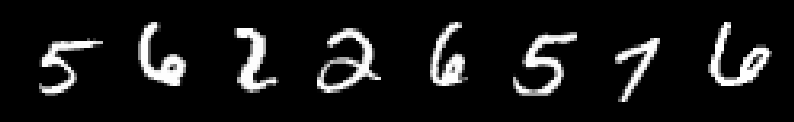

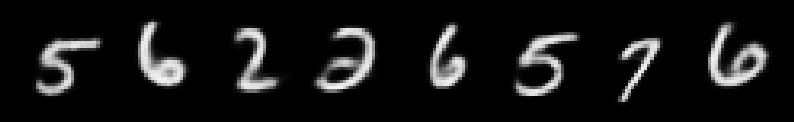

In [ ]:
# TEST
image, target = next(iter(test_loader)) # load one batch
image = image.to(device)

vae1.eval()

out, _, _ = vae1(image)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image[:8])
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out[:8])
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([8, 8])


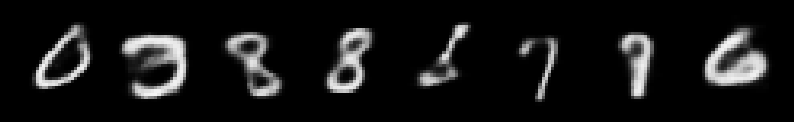

In [ ]:
# GENERATE!!!!
z = torch.randn(8,8).to(device)
print(z.size())
generated_samples = vae1.generate_img(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()


In [ ]:
# define Optimizer and Loss
optimizer = torch.optim.Adam(vae2.parameters(), lr=0.001)

# as loss lets use BCE (Binary Cross Entropy)
bce_loss = nn.BCELoss(reduction="sum")

In [ ]:
# TRAIN!!!

PATH = "./res/vae.pth"

vae2.train()

for epoch in range(10):
    for batch_idx, (data, target) in enumerate(train_loader):
        # send to device
        data = data.to(device)

        optimizer.zero_grad()
        output, log_var, mean = vae2(data)

        bce = bce_loss(output, data)
        kl = vae.KL_loss(log_var, mean)
        loss = bce + kl
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tBCE: {:.2f} KL: {:.2f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), bce.item(), kl.item()))

    # save model every epoch
    #torch.save(vae.state_dict(), PATH)

Train Epoch: 0 [0/60000 (0%)]	BCE: 34497.30 KL: 0.42
Train Epoch: 0 [12800/60000 (21%)]	BCE: 12913.07 KL: 0.00
Train Epoch: 0 [25600/60000 (43%)]	BCE: 13748.89 KL: 0.00
Train Epoch: 0 [38400/60000 (64%)]	BCE: 13127.13 KL: 0.00
Train Epoch: 0 [51200/60000 (85%)]	BCE: 14060.05 KL: 0.00
Train Epoch: 1 [0/60000 (0%)]	BCE: 13475.99 KL: 0.00
Train Epoch: 1 [12800/60000 (21%)]	BCE: 12896.73 KL: 0.00
Train Epoch: 1 [25600/60000 (43%)]	BCE: 13533.63 KL: 0.00
Train Epoch: 1 [38400/60000 (64%)]	BCE: 14096.89 KL: 0.00
Train Epoch: 1 [51200/60000 (85%)]	BCE: 12769.54 KL: 0.00
Train Epoch: 2 [0/60000 (0%)]	BCE: 13645.18 KL: 0.00
Train Epoch: 2 [12800/60000 (21%)]	BCE: 13095.44 KL: 0.00
Train Epoch: 2 [25600/60000 (43%)]	BCE: 12179.76 KL: 0.00
Train Epoch: 2 [38400/60000 (64%)]	BCE: 13974.29 KL: 0.00
Train Epoch: 2 [51200/60000 (85%)]	BCE: 13241.04 KL: 0.00
Train Epoch: 3 [0/60000 (0%)]	BCE: 12865.73 KL: 0.00
Train Epoch: 3 [12800/60000 (21%)]	BCE: 13533.17 KL: 0.00
Train Epoch: 3 [25600/60000 (43%)]

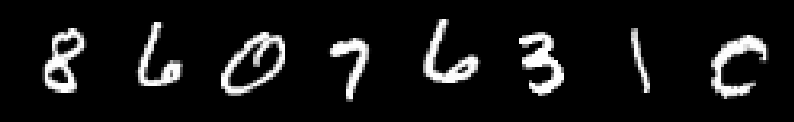

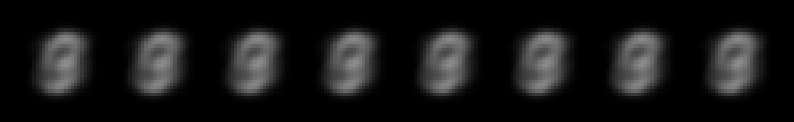

In [ ]:
# TEST
image, target = next(iter(test_loader)) # load one batch
image = image.to(device)

vae1.eval()

out, _, _ = vae2(image)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image[:8])
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out[:8])
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([8, 2])


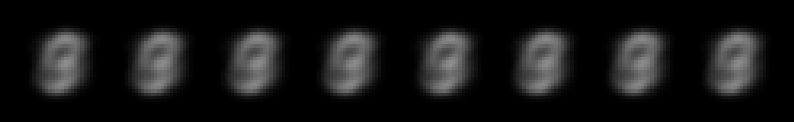

In [ ]:
# GENERATE!!!!
z = torch.randn(8,2).to(device)
print(z.size())
generated_samples = vae2.generate_img(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()

In [ ]:
# define Optimizer and Loss
optimizer = torch.optim.Adam(vae3.parameters(), lr=0.001)

# as loss lets use BCE (Binary Cross Entropy)
bce_loss = nn.BCELoss(reduction="sum")

In [ ]:
# TRAIN!!!

PATH = "./res/vae.pth"

vae3.train()

for epoch in range(10):
    for batch_idx, (data, target) in enumerate(train_loader):
        # send to device
        data = data.to(device)

        optimizer.zero_grad()
        output, log_var, mean = vae3(data)

        bce = bce_loss(output, data)
        kl = vae.KL_loss(log_var, mean)
        loss = bce + 20*kl
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tBCE: {:.2f} KL: {:.2f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), bce.item(), kl.item()))

    # save model every epoch
    #torch.save(vae.state_dict(), PATH)

Train Epoch: 0 [0/60000 (0%)]	BCE: 32360.34 KL: 0.70
Train Epoch: 0 [12800/60000 (21%)]	BCE: 13424.97 KL: 0.41
Train Epoch: 0 [25600/60000 (43%)]	BCE: 13530.10 KL: 4.13
Train Epoch: 0 [38400/60000 (64%)]	BCE: 13539.39 KL: 17.26
Train Epoch: 0 [51200/60000 (85%)]	BCE: 12223.60 KL: 10.58
Train Epoch: 1 [0/60000 (0%)]	BCE: 13055.78 KL: 12.57
Train Epoch: 1 [12800/60000 (21%)]	BCE: 13158.89 KL: 15.49
Train Epoch: 1 [25600/60000 (43%)]	BCE: 12928.92 KL: 17.71
Train Epoch: 1 [38400/60000 (64%)]	BCE: 13737.92 KL: 18.72
Train Epoch: 1 [51200/60000 (85%)]	BCE: 13221.23 KL: 18.73
Train Epoch: 2 [0/60000 (0%)]	BCE: 12166.18 KL: 17.53
Train Epoch: 2 [12800/60000 (21%)]	BCE: 12359.61 KL: 22.96
Train Epoch: 2 [25600/60000 (43%)]	BCE: 13008.63 KL: 20.21
Train Epoch: 2 [38400/60000 (64%)]	BCE: 12678.99 KL: 31.70
Train Epoch: 2 [51200/60000 (85%)]	BCE: 12575.60 KL: 21.53
Train Epoch: 3 [0/60000 (0%)]	BCE: 12862.78 KL: 28.71
Train Epoch: 3 [12800/60000 (21%)]	BCE: 12817.92 KL: 23.15
Train Epoch: 3 [2560

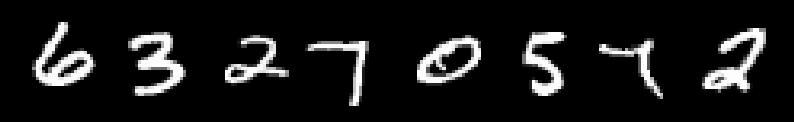

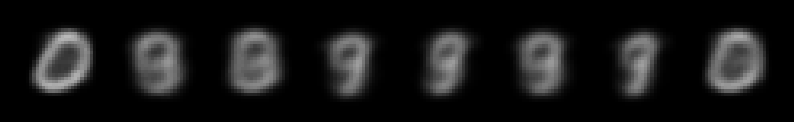

In [ ]:
# TEST
image, target = next(iter(test_loader)) # load one batch
image = image.to(device)

vae3.eval()

out, _, _ = vae3(image)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image[:8])
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out[:8])
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([8, 2])


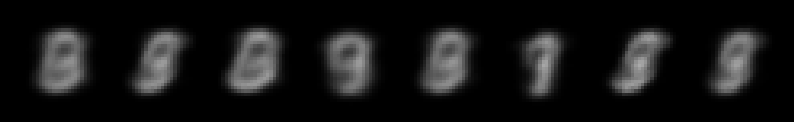

In [ ]:
# GENERATE!!!!
z = torch.randn(8,2).to(device)
print(z.size())
generated_samples = vae3.generate_img(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()

In [ ]:
# Ex2: train the VAE on Cifar10 (latent space of dim 2 is enough?)

In [ ]:
import torch.nn as nn
import torch.nn.init as init

def reset_weights(m):
    if isinstance(m, nn.Linear):
        init.kaiming_uniform_(m.weight)  # o init.xavier_uniform_(m.weight)
        if m.bias is not None:
            init.zeros_(m.bias)

vae4.apply(reset_weights)

VAE4(
  (Encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(2, 2))
    (7): ReLU()
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(2, 2))
    (9): ReLU()
    (10): Conv2d(256, 64, kernel_size=(4, 4), stride=(1, 1))
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=128, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=128, bias=True)
  (resize_fc): Linear(in_features=128, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), p

In [ ]:
# Load MNIST dataset
# TRAIN dataset
# Pytorch already has some datasets available for downlaod
train_dataset_cifar10 = datasets.CIFAR10('../data', train=True, download=True,
                # transforms that we want to apply when iterating the dataset
                   transform=transforms.ToTensor())

# The datasoar will iterate through the dataset and load the data in memory
train_loader_cifar10 = torch.utils.data.DataLoader(
                        train_dataset_cifar10,
                        batch_size=64, shuffle=True)

# TEST dataset
test_loader_cifar10 = torch.utils.data.DataLoader(
    datasets.CIFAR10('../data', train=False,
                   transform=transforms.ToTensor()),
                    batch_size=1000, shuffle=True)

100%|██████████| 170M/170M [00:01<00:00, 89.6MB/s]


In [ ]:
# Let's define our VAE

class VAE4(nn.Module):
    def __init__(
        self,
        image_channels=3,
        hidden_size=64,
        latent_size=128
    ):
        super(VAE4, self).__init__()

        self.hidden_size = hidden_size
        self.latent_size = latent_size

        ## encoder ##
        self.Encoder = nn.Sequential(nn.Conv2d(image_channels, 16, 3, stride = 1, padding=1), #16x16x16   [(W−K+2P)/S]+1
                                        nn.ReLU(),
                                        nn.Conv2d(16, 32, 2, stride = 2, padding=1), #32x17x17
                                        nn.ReLU(),
                                        nn.Conv2d(32, 64, 4, stride = 2, padding=1), #64x8x8
                                        nn.ReLU(),
                                        nn.Conv2d(64, 128, 3, stride = 2, padding=2), #128x5x5
                                        nn.ReLU(),
                                        nn.Conv2d(128, 256, 3, stride = 2, padding=2), #64x4x4
                                        nn.ReLU(),
                                        nn.Conv2d(256, self.hidden_size, 4, stride = 1, padding=0), #64x1x1
                                        nn.ReLU(),
                                        nn.Flatten())  #hidden_size


        # define mean
        self.encoder_mean = nn.Linear(self.hidden_size, self.latent_size)
        #define logvar
        self.encoder_logvar = nn.Linear(self.hidden_size, self.latent_size)

        self.resize_fc = nn.Linear(self.latent_size, self.hidden_size)

        ## decoder ##
        self.Decoder = nn.Sequential(nn.ConvTranspose2d( self.hidden_size, 64, 4, 1, 0), #4x4  (W - 1)S -2P + (K - 1) + 1
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 64, 32, 3, 2, 1, output_padding=1), #7x7
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 32, 16, 4, 2, 1), #14x14
                                    nn.ReLU(),
                                    nn.ConvTranspose2d( 16, 3, 4, 2, 1), #28x28
                                    nn.Sigmoid())

    def sample(self, log_var, mean):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean) # reparametrization trick

    def KL_loss(self, log_var, mean):
        return -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())

    def forward(self, x):
        x = self.Encoder(x)
        log_var = self.encoder_logvar(x)
        mean = self.encoder_mean(x)

        z = self.sample(log_var, mean)

        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)

        x = self.Decoder(x)

        return x, log_var, mean

    def generate_img(self, z):
        x = self.resize_fc(z).view(z.size(0),self.hidden_size,1,1)
        return self.Decoder(x)


vae4 = VAE4().to(device)
print(vae4)

VAE4(
  (Encoder): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(2, 2))
    (7): ReLU()
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(2, 2))
    (9): ReLU()
    (10): Conv2d(256, 64, kernel_size=(4, 4), stride=(1, 1))
    (11): ReLU()
    (12): Flatten(start_dim=1, end_dim=-1)
  )
  (encoder_mean): Linear(in_features=64, out_features=128, bias=True)
  (encoder_logvar): Linear(in_features=64, out_features=128, bias=True)
  (resize_fc): Linear(in_features=128, out_features=64, bias=True)
  (Decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), p

In [ ]:
# define Optimizer and Loss
optimizer = torch.optim.Adam(vae4.parameters(), lr=0.001)

# as loss lets use BCE (Binary Cross Entropy)
bce_loss = nn.BCEWithLogitsLoss(reduction="sum")

In [ ]:
# TRAIN!!!

PATH = "./res/vae.pth"

vae4.train()

for epoch in range(10):
    for batch_idx, (data, target) in enumerate(train_loader_cifar10):
        # send to device
        data = data.to(device)
        optimizer.zero_grad()
        output, log_var, mean = vae4(data)

        bce = bce_loss(output, data)
        kl = vae4.KL_loss(log_var, mean)
        loss = bce + kl
        loss.backward()
        optimizer.step()
        if batch_idx % 200 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tBCE: {:.2f} KL: {:.2f}'.format(
                epoch, batch_idx * len(data), len(train_loader_cifar10.dataset),
                100. * batch_idx / len(train_loader_cifar10), bce.item(), kl.item()))

    # save model every epoch
    #torch.save(vae.state_dict(), PATH)

Train Epoch: 0 [0/50000 (0%)]	BCE: 145696.59 KL: 34.46
Train Epoch: 0 [12800/50000 (26%)]	BCE: 132868.69 KL: 301.80
Train Epoch: 0 [25600/50000 (51%)]	BCE: 133080.86 KL: 317.09
Train Epoch: 0 [38400/50000 (77%)]	BCE: 130154.84 KL: 567.28
Train Epoch: 1 [0/50000 (0%)]	BCE: 132895.02 KL: 487.77
Train Epoch: 1 [12800/50000 (26%)]	BCE: 130105.14 KL: 593.34
Train Epoch: 1 [25600/50000 (51%)]	BCE: 130683.68 KL: 533.82


KeyboardInterrupt: 

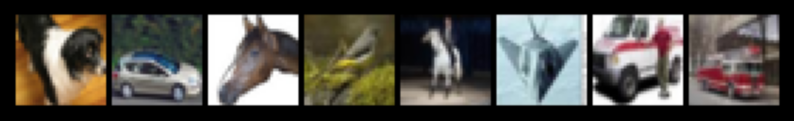

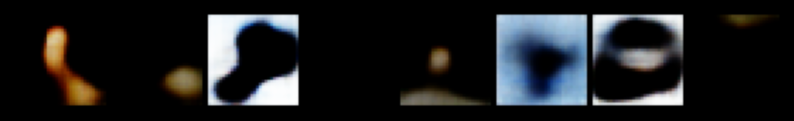

In [ ]:
# TEST
image, target = next(iter(test_loader_cifar10)) # load one batch
image = image.to(device)

vae4.eval()

out, _, _ = vae4(image)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image[:8])
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out[:8])
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([8, 128])


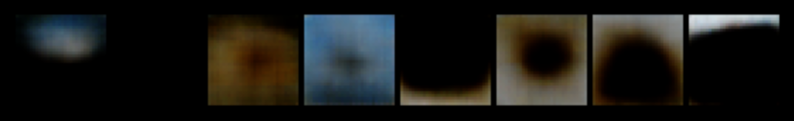

In [ ]:
# GENERATE!!!!
z = torch.randn(8,128).to(device)
print(z.size())
generated_samples = vae4.generate_img(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE5(nn.Module):
    def __init__(self, image_channels=3, latent_size=128):
        super().__init__()
        # Encoder: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.enc = nn.Sequential(
            nn.Conv2d(image_channels, 32, 3, stride=2, padding=1),  # 32x16x16
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),              # 64x8x8
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),             # 128x4x4
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
        )
        self.flat_dim = 128*4*4
        self.to_mu     = nn.Linear(self.flat_dim, latent_size)
        self.to_logvar = nn.Linear(self.flat_dim, latent_size)

        # Decoder: FC -> 4x4 -> 8x8 -> 16x16 -> 32x32
        self.from_z = nn.Linear(latent_size, self.flat_dim)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # 8x8
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # 16x16
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2, inplace=True),
            nn.ConvTranspose2d(32, image_channels, 4, stride=2, padding=1) # 32x32
            # NIENTE Sigmoid -> useremo BCEWithLogitsLoss
        )

        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
            if m.bias is not None: nn.init.zeros_(m.bias)
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        mu = self.to_mu(h)
        logvar = self.to_logvar(h)
        return mu, logvar

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_logits(self, z):
        h = self.from_z(z).view(z.size(0), 128, 4, 4)
        logits = self.dec(h)  # logits (no sigmoid)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar

    @torch.no_grad()
    def generate(self, z):
        # restituisce immagini in [0,1] per visualizzazione
        logits = self.decode_logits(z)
        return torch.sigmoid(logits)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae5 = VAE5(image_channels=3, latent_size=128).to(device)

optimizer = torch.optim.AdamW(vae5.parameters(), lr=1e-3, weight_decay=1e-4)
bce_logits = nn.BCEWithLogitsLoss(reduction='sum')

num_epochs = 50
for epoch in range(num_epochs):
    vae5.train()
    beta = min(1.0, epoch / 10.0)  # annealing: 0->1 in ~10 epoche
    for batch_idx, (data, _) in enumerate(train_loader_cifar10):
        # Assicurati che 'data' sia in [0,1]; niente Normalize(0.5)
        data = data.to(device)

        logits, mu, logvar = vae5(data)
        # Ricostruzione (per-pixel Bernoulli)
        recon = bce_logits(logits, data) / data.size(0)

        # KL per batch
        kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / data.size(0)

        loss = recon + beta * kl

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(vae5.parameters(), 5.0)
        optimizer.step()

        if batch_idx % 200 == 0:
            print(f"Epoch {epoch:02d} [{batch_idx*len(data):5d}]  recon={recon.item():.2f}  kl={kl.item():.2f}  beta={beta:.2f}")


Epoch 00 [    0]  recon=2839.82  kl=102.65  beta=0.00
Epoch 00 [12800]  recon=1781.96  kl=1420.86  beta=0.00
Epoch 00 [25600]  recon=1733.26  kl=1495.64  beta=0.00
Epoch 00 [38400]  recon=1751.16  kl=1567.07  beta=0.00
Epoch 01 [    0]  recon=1752.00  kl=1668.30  beta=0.10
Epoch 01 [12800]  recon=1775.54  kl=220.27  beta=0.10
Epoch 01 [25600]  recon=1738.17  kl=209.21  beta=0.10
Epoch 01 [38400]  recon=1722.18  kl=202.42  beta=0.10
Epoch 02 [    0]  recon=1713.70  kl=197.41  beta=0.20
Epoch 02 [12800]  recon=1782.38  kl=162.83  beta=0.20
Epoch 02 [25600]  recon=1739.47  kl=150.85  beta=0.20
Epoch 02 [38400]  recon=1734.11  kl=149.42  beta=0.20
Epoch 03 [    0]  recon=1792.37  kl=153.57  beta=0.30
Epoch 03 [12800]  recon=1720.09  kl=125.12  beta=0.30
Epoch 03 [25600]  recon=1709.05  kl=123.06  beta=0.30
Epoch 03 [38400]  recon=1726.54  kl=122.58  beta=0.30
Epoch 04 [    0]  recon=1743.21  kl=118.95  beta=0.40
Epoch 04 [12800]  recon=1730.93  kl=97.71  beta=0.40
Epoch 04 [25600]  recon=1

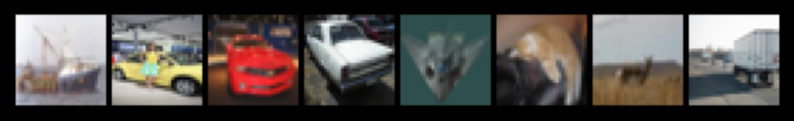

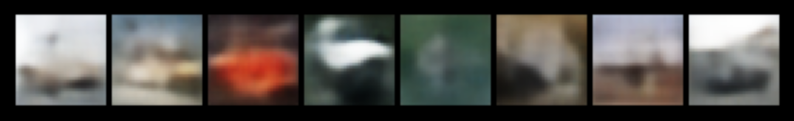

In [ ]:
# TEST
image, target = next(iter(test_loader_cifar10)) # load one batch
image = image.to(device)[:8]

vae5.eval()

with torch.no_grad():
  out, _, _ = vae5(image)
  out = torch.sigmoid(out)

# input
plt.figure()
image_grid = torchvision.utils.make_grid(image)
plt.imshow(to_pil(image_grid))
plt.axis("off")
plt.show()

# output
plt.figure()
out_grid = torchvision.utils.make_grid(out)
plt.imshow(to_pil(out_grid))
plt.axis("off")
plt.show()

torch.Size([64, 128])


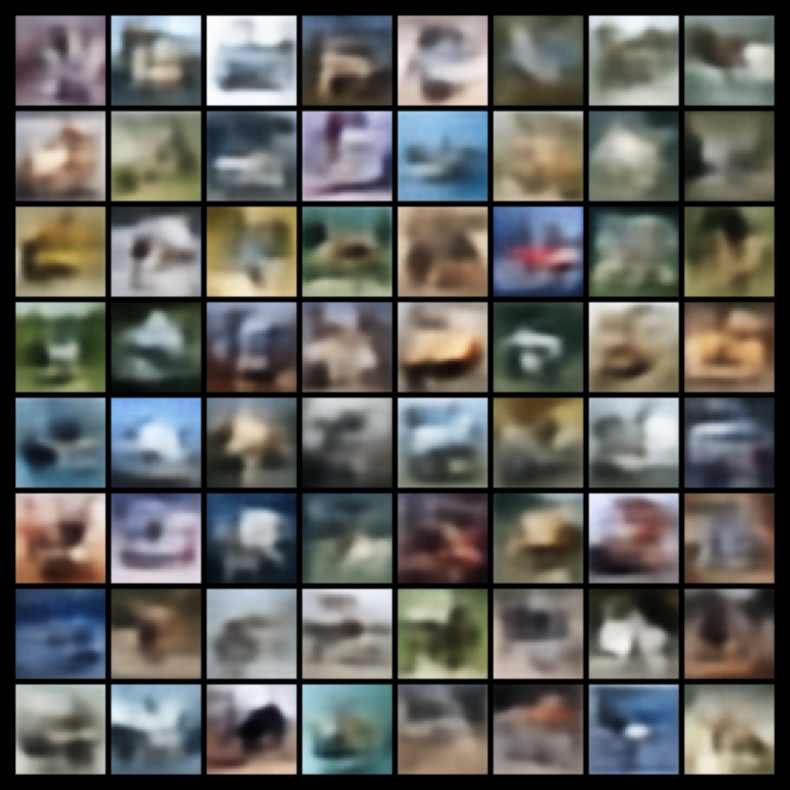

In [ ]:
# GENERATE!!!!
z = torch.randn(64,128).to(device)
print(z.size())
generated_samples = vae5.generate(z)

plt.figure()
gen_grid = torchvision.utils.make_grid(generated_samples)
plt.imshow(to_pil(gen_grid))
plt.axis("off")
plt.show()